
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [ ]:
isla = df[df["isla"] == "Torgersen"]
print("La profundidad del pico maximo es:", isla["profundidad_pico (mm)"].max())
print("La profundidad del pico minimo es:", isla["profundidad_pico (mm)"].min())

La profundidad del pico maximo es: 21.5
La profundidad del pico minimo es: 15.9


In [ ]:
print("Las caracteristicas del pinguino con mayor masa corporal son:")
df[df["masa_corporal (g)"] == df["masa_corporal (g)"].max()].drop(columns=["longitud_pico (mm)","profundidad_pico (mm)","longitud_aleta (mm)"])

Las caracteristicas del pinguino con mayor masa corporal son:


,especie,isla,masa_corporal (g),genero
231,Gentoo,Biscoe,6300.0,Male


In [ ]:
filtro = df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]
print("La masa corporal media de los pinguinos macho que no pertenecen a la especie Gentoo es de: ", filtro["masa_corporal (g)"].mean())

La masa corporal media de los pinguinos macho que no pertenecen a la especie Gentoo es de:  4010.2803738317757


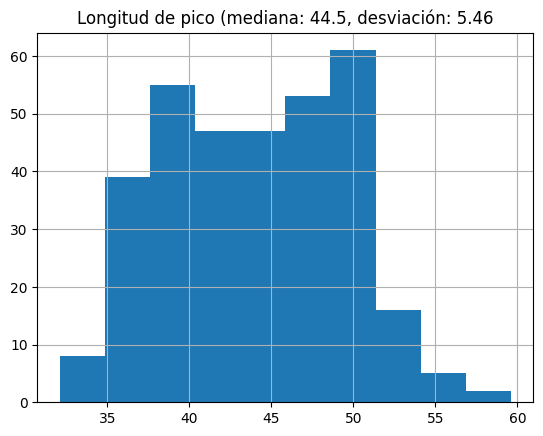

In [ ]:
pico = df["longitud_pico (mm)"]
plt.hist(pico)
plt.title(f"Longitud de pico (mediana: {np.median(pico)}, desviación: {np.std(pico).round(2)}")
plt.grid()
plt.show()

In [ ]:
especies = [df["especie"][0]]
for i in range(1,len(df["especie"])):
  if especies[len(especies)-1] != df["especie"][i]:
    especies.append(df["especie"][i])
conteo = pd.DataFrame([{especies[0], len(df[df["especie"] == "Adelie"])}, {especies[1], len(df[df["especie"] == "Gentoo"])}, {especies[2], len(df[df["especie"] == "Chinstrap"])}])
conteo

,0,1
0,Adelie,146
1,Chinstrap,119
2,Gentoo,68


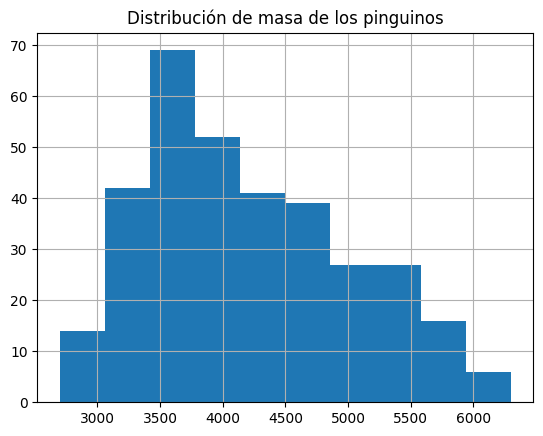

In [ ]:
plt.hist(df["masa_corporal (g)"])
plt.title("Distribución de masa de los pinguinos")
plt.grid()
plt.show()